In [1]:
%matplotlib widget

In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os
from astropy.modeling import models
import astropy.units as u

In [2]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC7596/UGC7596_1/UGC-7596_1_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC7596/UGC7596_1/UGC-7596_1_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     359   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        58   (2094, 964)   float32   


In [3]:
image_cut = image[77:177, 0:1890]
image_error_cut = image_error[77:177, 0:1890]

Text(0.5, 0, 'wavelenght')

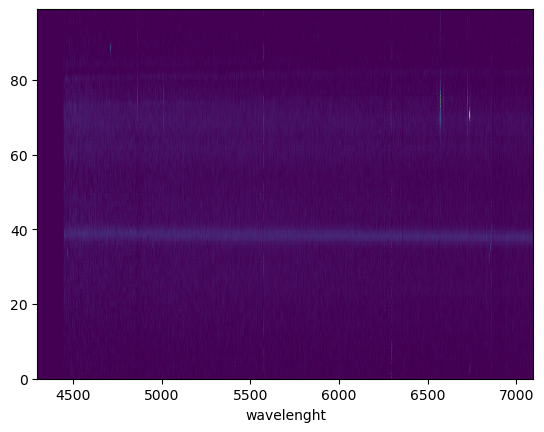

In [4]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

In [5]:
z = 0.00189
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII_1 = 6548 * (1+z) 
l_NII_2 = 6583 * (1+z)
l_SII_1 = 6717 * (1+z)
l_SII_2 = 6731 * (1+z)
l_OIII_1 = 4959 * (1+z)
l_OIII_2 = 5007 * (1+z)

Text(0, 0.5, 'Flux [$10^{-16} erg/(cm^2 s \\AA )$]')

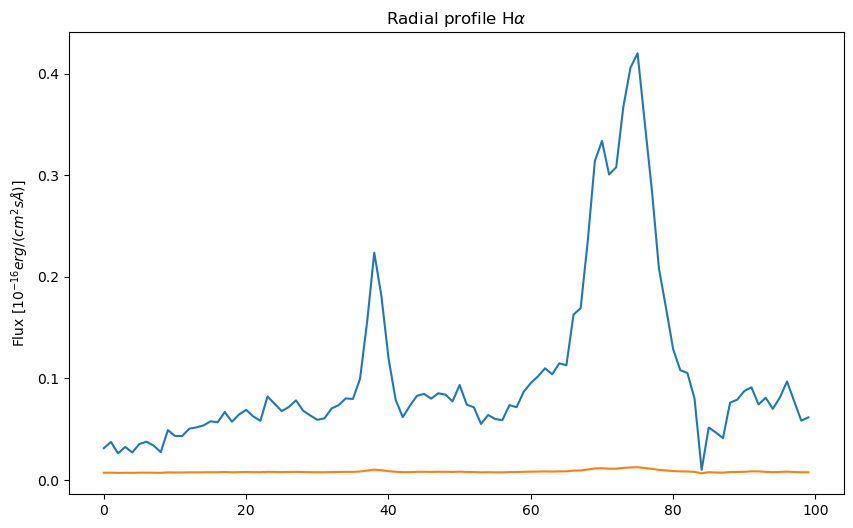

In [6]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'Radial profile H$\alpha$')
plt.ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')

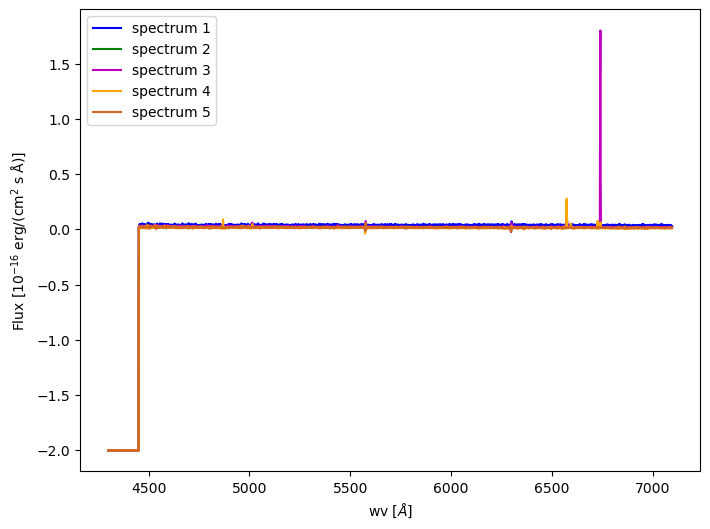

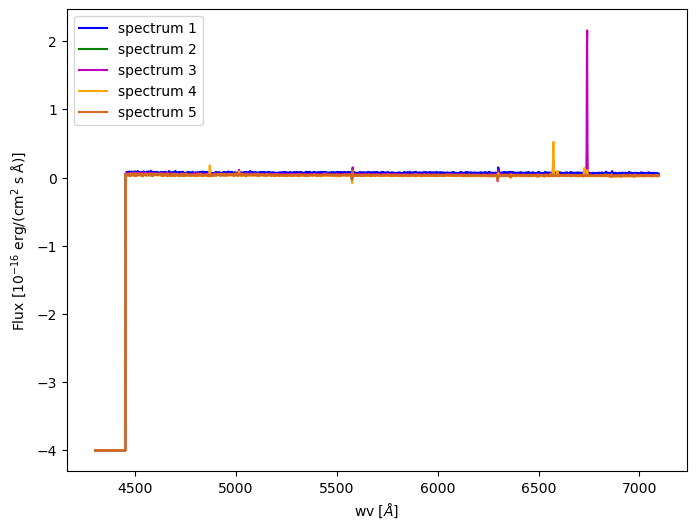

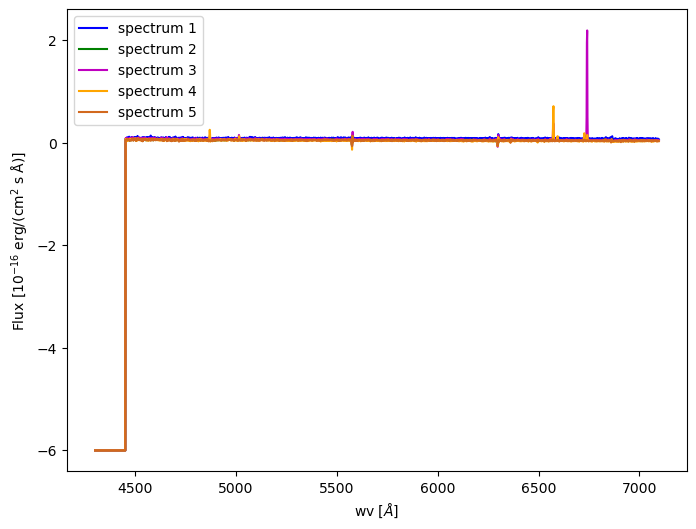

In [7]:
fit_OIII = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC7596/UGC7596_1/Fit/OIII_fit.csv", index_col=0)
os.makedirs('1Sigma', exist_ok=True)
os.makedirs('2Sigma', exist_ok=True)
os.makedirs('3Sigma', exist_ok=True)

seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC7596/PSF/Real_seeing_UGC7596.txt")
sigma = seeing[-1] / 2.35
peaks = fit_OIII.iloc[3].values

plt.figure(figsize=(8,6))
spectra_1 =  np.zeros((len(peaks), image_cut.shape[1]))
spectra_err_1 = np.zeros((len(peaks), image_error_cut.shape[1]))
data1 = []
colors = ['blue', 'green','m', 'orange', 'chocolate', 'dodgerblue', 'deeppink']
#Cut one sigma 
for i in range(len(peaks)):
    mask = (x_axes > peaks[i]-sigma)*(x_axes < peaks[i]+sigma)
    spectra_1[i] = np.sum(image_cut[mask, :], axis = 0)
    spectra_err_1[i] = np.sqrt(np.sum(image_error_cut[mask, :]**2, axis = 0)) #The error is the squared sum of the errors of each pixels (y) 
    plt.plot(wv, spectra_1[i], color = colors[i], label = f'spectrum {i+1}')
    plt.legend()
    plt.xlabel(r'wv [$\AA$]')
    plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
    
    spectrum_table = np.concatenate((wv.reshape(-1, 1), 
                                    spectra_1[i].reshape(-1, 1), spectra_err_1[i].reshape(-1, 1)), axis=1)
    filename = os.path.join('1Sigma', f'Spectrum_1s_{i+1}.txt')  
    np.savetxt(filename, spectrum_table)

plt.figure(figsize=(8,6))
spectra_2 =  np.zeros((len(peaks), image_cut.shape[1]))
spectra_err_2 = np.zeros((len(peaks), image_error_cut.shape[1]))
data2 = []

#Cut two sigma 
for i in range(len(peaks)):
    mask = (x_axes > peaks[i]-2*sigma)*(x_axes < peaks[i]+2*sigma)
    spectra_2[i] = np.sum(image_cut[mask, :], axis = 0)
    spectra_err_2[i] = np.sqrt(np.sum(image_error_cut[mask, :]**2, axis = 0)) #The error is the squared sum of the errors of each pixels (y) 
    plt.plot(wv, spectra_2[i], color = colors[i], label = f'spectrum {i+1}')
    plt.legend()
    plt.xlabel(r'wv [$\AA$]')
    plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
    
    spectrum_table = np.concatenate((wv.reshape(-1, 1), 
                                    spectra_2[i].reshape(-1, 1), spectra_err_2[i].reshape(-1, 1)), axis=1)
    filename = os.path.join('2Sigma', f'Spectrum_2s_{i+1}.txt')  
    np.savetxt(filename, spectrum_table)
    
plt.figure(figsize=(8,6))
spectra_3 =  np.zeros((len(peaks), image_cut.shape[1]))
spectra_err_3 = np.zeros((len(peaks), image_error_cut.shape[1]))
data3 = []
#Cut three sigma 
for i in range(len(peaks)):
    mask = (x_axes > peaks[i]-3*sigma)*(x_axes < peaks[i]+3*sigma)
    spectra_3[i] = np.sum(image_cut[mask, :], axis = 0)
    spectra_err_3[i] = np.sqrt(np.sum(image_error_cut[mask, :]**2, axis = 0)) #The error is the squared sum of the errors of each pixels (y) 
    plt.plot(wv, spectra_3[i], color = colors[i], label = f'spectrum {i+1}')
    plt.legend()
    plt.xlabel(r'wv [$\AA$]')
    plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
    
    spectrum_table = np.concatenate((wv.reshape(-1, 1), 
                                    spectra_3[i].reshape(-1, 1), spectra_err_3[i].reshape(-1, 1)), axis=1)
    filename = os.path.join('3Sigma', f'Spectrum_3s_{i+1}.txt') 
    np.savetxt(filename, spectrum_table)

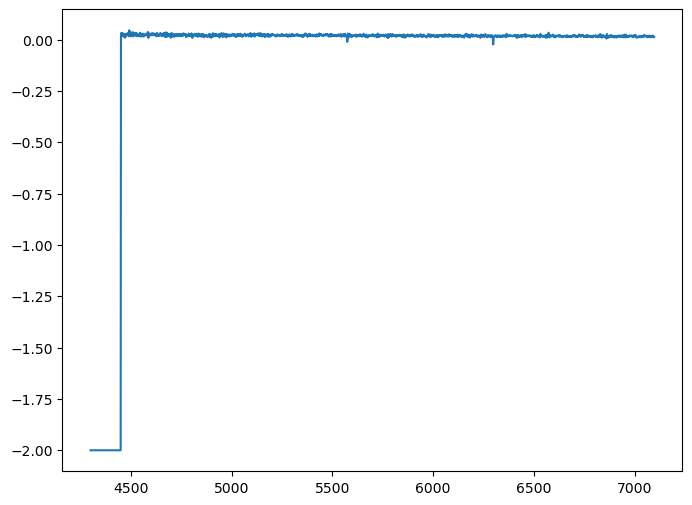

In [8]:
plt.figure(figsize=(8,6))
plt.plot(wv, spectra_1[1])

## S/N continuum
Fare segnale/rumore per ogni pixel e poi fai la media, questo per le tre regioni

In [9]:
import pandas as pd

mask_continuum_1 = (wv > 4500)*(wv < 4800)
mask_continuum_2 = (wv > 5100)*(wv < 5400)
mask_continuum_3 = (wv > 5810)*(wv < 6210)

# Liste per contenere i risultati
SNR = []
Signal = []
Noise = []

# Calcolo per ogni spettro
for i in range(len(peaks)):  # Assumendo che peaks definisca il numero di spettri
    snr = []
    signal = []
    noise = []
    
    # Calcolo per continuum_1
    sig_1 = np.mean(spectra_1[i, mask_continuum_1])
    noise_1 = np.std(spectra_1[i, mask_continuum_1])
    snr_1 = sig_1 / noise_1
    
    # Calcolo per continuum_2  
    sig_2 = np.mean(spectra_1[i, mask_continuum_2])
    noise_2 = np.std(spectra_1[i, mask_continuum_2])
    snr_2 = sig_2 / noise_2
    
    # Calcolo per continuum_3
    sig_3 = np.mean(spectra_1[i, mask_continuum_3])
    noise_3 = np.std(spectra_1[i, mask_continuum_3])
    snr_3 = sig_3 / noise_3
    
    # Aggiunta ai risultati
    snr.extend([snr_1, snr_2, snr_3])
    signal.extend([sig_1, sig_2, sig_3])
    noise.extend([noise_1, noise_2, noise_3])
    
    SNR.append(snr)
    Signal.append(signal)
    Noise.append(noise)

# Conversione in array numpy e trasposizione
SNR_array = np.array(SNR).T  # Trasponi per avere continuum come righe
Signal_array = np.array(Signal).T
Noise_array = np.array(Noise).T

# Creazione del DataFrame
# Nomi delle colonne per ogni spettro
col_names = [f'Spectrum_{i+1}' for i in range(len(peaks))]

# Creazione di DataFrames separati per ogni metrica
df_snr = pd.DataFrame(SNR_array, 
                      columns=col_names,
                      index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df_signal = pd.DataFrame(Signal_array, 
                         columns=col_names,
                         index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df_noise = pd.DataFrame(Noise_array, 
                        columns=col_names,
                        index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

# Combinazione in un unico DataFrame con MultiIndex per le colonne
df_combined = pd.concat([df_snr, df_signal, df_noise], 
                        keys=['SNR', 'Signal', 'Noise'], 
                        axis=1)

print("DataFrame SNR:")
print(df_snr)
print("\nDataFrame Signal:")
print(df_signal)
print("\nDataFrame Noise:")
print(df_noise)
print("\nDataFrame Combinato:")
print(df_combined)

# Salvataggio dei file
df_path_snr = os.path.join('1Sigma', 'SNR_1s_continuum.csv')
df_path_signal = os.path.join('1Sigma', 'Signal_1s_continuum.csv')
df_path_noise = os.path.join('1Sigma', 'Noise_1s_continuum.csv')
df_path_combined = os.path.join('1Sigma', 'Combined_1s_continuum.csv')

# Assicurati che la directory esista
os.makedirs('1Sigma', exist_ok=True)

df_snr.to_csv(df_path_snr, float_format='%.3f')
df_signal.to_csv(df_path_signal, float_format='%.3f')
df_noise.to_csv(df_path_noise, float_format='%.3f')
df_combined.to_csv(df_path_combined, float_format='%.3f')

print(f"\nFile salvati in:")
print(f"- {df_path_snr}")
print(f"- {df_path_signal}")
print(f"- {df_path_noise}")
print(f"- {df_path_combined}")

DataFrame SNR:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4  Spectrum_5
Continuum_1    6.373401    4.348004    4.838698    3.565534    3.701138
Continuum_2    9.412392    5.685708    6.132350    4.593358    4.528500
Continuum_3   10.214309    5.314194    6.082008    4.095589    4.807953

DataFrame Signal:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4  Spectrum_5
Continuum_1    0.039152    0.022748    0.026075    0.017525    0.018970
Continuum_2    0.039577    0.021181    0.022880    0.015587    0.016850
Continuum_3    0.040008    0.018477    0.020666    0.013507    0.015787

DataFrame Noise:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4  Spectrum_5
Continuum_1    0.006143    0.005232    0.005389    0.004915    0.005125
Continuum_2    0.004205    0.003725    0.003731    0.003393    0.003721
Continuum_3    0.003917    0.003477    0.003398    0.003298    0.003283

DataFrame Combinato:
                   SNR                                        

In [10]:
# Liste per contenere i risultati
SNR = []
Signal = []
Noise = []

# Calcolo per ogni spettro
for i in range(len(peaks)):  # Assumendo che peaks definisca il numero di spettri
    snr = []
    signal = []
    noise = []
    
    # Calcolo per continuum_1
    sig_1 = np.mean(spectra_2[i, mask_continuum_1])
    noise_1 = np.std(spectra_2[i, mask_continuum_1])
    snr_1 = sig_1 / noise_1
    
    # Calcolo per continuum_2  
    sig_2 = np.mean(spectra_2[i, mask_continuum_2])
    noise_2 = np.std(spectra_2[i, mask_continuum_2])
    snr_2 = sig_2 / noise_2
    
    # Calcolo per continuum_3
    sig_3 = np.mean(spectra_2[i, mask_continuum_3])
    noise_3 = np.std(spectra_2[i, mask_continuum_3])
    snr_3 = sig_3 / noise_3
    
    # Aggiunta ai risultati
    snr.extend([snr_1, snr_2, snr_3])
    signal.extend([sig_1, sig_2, sig_3])
    noise.extend([noise_1, noise_2, noise_3])
    
    SNR.append(snr)
    Signal.append(signal)
    Noise.append(noise)

# Conversione in array numpy e trasposizione
SNR_array = np.array(SNR).T  # Trasponi per avere continuum come righe
Signal_array = np.array(Signal).T
Noise_array = np.array(Noise).T

# Creazione del DataFrame
# Nomi delle colonne per ogni spettro
col_names = [f'Spectrum_{i+1}' for i in range(len(peaks))]

# Creazione di DataFrames separati per ogni metrica
df_snr = pd.DataFrame(SNR_array, 
                      columns=col_names,
                      index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df_signal = pd.DataFrame(Signal_array, 
                         columns=col_names,
                         index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df_noise = pd.DataFrame(Noise_array, 
                        columns=col_names,
                        index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

# Combinazione in un unico DataFrame con MultiIndex per le colonne
df_combined = pd.concat([df_snr, df_signal, df_noise], 
                        keys=['SNR', 'Signal', 'Noise'], 
                        axis=1)

print("DataFrame SNR:")
print(df_snr)
print("\nDataFrame Signal:")
print(df_signal)
print("\nDataFrame Noise:")
print(df_noise)
print("\nDataFrame Combinato:")
print(df_combined)

# Salvataggio dei file
df_path_snr = os.path.join('2Sigma', 'SNR_2s_continuum.csv')
df_path_signal = os.path.join('2Sigma', 'Signal_2s_continuum.csv')
df_path_noise = os.path.join('2Sigma', 'Noise_2s_continuum.csv')
df_path_combined = os.path.join('2Sigma', 'Combined_2s_continuum.csv')

# Assicurati che la directory esista
os.makedirs('2Sigma', exist_ok=True)

df_snr.to_csv(df_path_snr, float_format='%.3f')
df_signal.to_csv(df_path_signal, float_format='%.3f')
df_noise.to_csv(df_path_noise, float_format='%.3f')
df_combined.to_csv(df_path_combined, float_format='%.3f')

print(f"\nFile salvati in:")
print(f"- {df_path_snr}")
print(f"- {df_path_signal}")
print(f"- {df_path_noise}")
print(f"- {df_path_combined}")

DataFrame SNR:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4  Spectrum_5
Continuum_1    7.354607    5.604720    6.078446    4.874291    4.491091
Continuum_2   11.070033    7.187573    7.683516    6.339990    6.305326
Continuum_3   11.840035    7.595051    7.745590    5.290972    6.805655

DataFrame Signal:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4  Spectrum_5
Continuum_1    0.069436    0.044706    0.051656    0.037413    0.038149
Continuum_2    0.068928    0.040846    0.045308    0.033639    0.034100
Continuum_3    0.067870    0.036197    0.039984    0.027462    0.031853

DataFrame Noise:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4  Spectrum_5
Continuum_1    0.009441    0.007976    0.008498    0.007676    0.008494
Continuum_2    0.006227    0.005683    0.005897    0.005306    0.005408
Continuum_3    0.005732    0.004766    0.005162    0.005190    0.004680

DataFrame Combinato:
                   SNR                                        

In [11]:
# Liste per contenere i risultati
SNR = []
Signal = []
Noise = []

# Calcolo per ogni spettro
for i in range(len(peaks)):  # Assumendo che peaks definisca il numero di spettri
    snr = []
    signal = []
    noise = []
    
    # Calcolo per continuum_1
    sig_1 = np.mean(spectra_3[i, mask_continuum_1])
    noise_1 = np.std(spectra_3[i, mask_continuum_1])
    snr_1 = sig_1 / noise_1
    
    # Calcolo per continuum_2  
    sig_2 = np.mean(spectra_3[i, mask_continuum_2])
    noise_2 = np.std(spectra_3[i, mask_continuum_2])
    snr_2 = sig_2 / noise_2
    
    # Calcolo per continuum_3
    sig_3 = np.mean(spectra_3[i, mask_continuum_3])
    noise_3 = np.std(spectra_3[i, mask_continuum_3])
    snr_3 = sig_3 / noise_3
    
    # Aggiunta ai risultati
    snr.extend([snr_1, snr_2, snr_3])
    signal.extend([sig_1, sig_2, sig_3])
    noise.extend([noise_1, noise_2, noise_3])
    
    SNR.append(snr)
    Signal.append(signal)
    Noise.append(noise)

# Conversione in array numpy e trasposizione
SNR_array = np.array(SNR).T  # Trasponi per avere continuum come righe
Signal_array = np.array(Signal).T
Noise_array = np.array(Noise).T

# Creazione del DataFrame
# Nomi delle colonne per ogni spettro
col_names = [f'Spectrum_{i+1}' for i in range(len(peaks))]

# Creazione di DataFrames separati per ogni metrica
df_snr = pd.DataFrame(SNR_array, 
                      columns=col_names,
                      index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df_signal = pd.DataFrame(Signal_array, 
                         columns=col_names,
                         index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df_noise = pd.DataFrame(Noise_array, 
                        columns=col_names,
                        index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

# Combinazione in un unico DataFrame con MultiIndex per le colonne
df_combined = pd.concat([df_snr, df_signal, df_noise], 
                        keys=['SNR', 'Signal', 'Noise'], 
                        axis=1)

print("DataFrame SNR:")
print(df_snr)
print("\nDataFrame Signal:")
print(df_signal)
print("\nDataFrame Noise:")
print(df_noise)
print("\nDataFrame Combinato:")
print(df_combined)

# Salvataggio dei file
df_path_snr = os.path.join('3Sigma', 'SNR_3s_continuum.csv')
df_path_signal = os.path.join('3Sigma', 'Signal_3s_continuum.csv')
df_path_noise = os.path.join('3Sigma', 'Noise_3s_continuum.csv')
df_path_combined = os.path.join('3Sigma', 'Combined_3s_continuum.csv')

# Assicurati che la directory esista
os.makedirs('3Sigma', exist_ok=True)

df_snr.to_csv(df_path_snr, float_format='%.3f')
df_signal.to_csv(df_path_signal, float_format='%.3f')
df_noise.to_csv(df_path_noise, float_format='%.3f')
df_combined.to_csv(df_path_combined, float_format='%.3f')

print(f"\nFile salvati in:")
print(f"- {df_path_snr}")
print(f"- {df_path_signal}")
print(f"- {df_path_noise}")
print(f"- {df_path_combined}")

DataFrame SNR:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4  Spectrum_5
Continuum_1    7.888713    6.240067    6.930435    5.490510    5.067276
Continuum_2   12.049225    8.209881    9.292201    7.502154    7.714832
Continuum_3   12.576913    8.742917    8.745814    6.259492    8.181018

DataFrame Signal:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4  Spectrum_5
Continuum_1    0.093396    0.065381    0.075926    0.057367    0.057168
Continuum_2    0.090511    0.058988    0.066826    0.050650    0.052396
Continuum_3    0.087019    0.052846    0.058343    0.040937    0.048182

DataFrame Noise:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4  Spectrum_5
Continuum_1    0.011839    0.010478    0.010955    0.010448    0.011282
Continuum_2    0.007512    0.007185    0.007192    0.006751    0.006792
Continuum_3    0.006919    0.006044    0.006671    0.006540    0.005889

DataFrame Combinato:
                   SNR                                        

## Redshift

In [8]:
from astropy.modeling import models
import astropy.units as u
from specutils import Spectrum
import astropy.units as u
from specutils.fitting import find_lines_threshold, fit_generic_continuum
from specutils.manipulation import noise_region_uncertainty
from astropy.nddata import StdDevUncertainty
from astropy.modeling.fitting import LinearLSQFitter

Numero di righe trovate (regione centrale, wv > 4451 Å): 17
   line_center    line_type  line_center_index
     Angstrom                                 
----------------- ---------- -----------------
4380.659999999976   emission                36
5067.379999999774   emission               500
6827.099999999255   emission              1689
 6841.89999999925   emission              1699
6862.619999999244   emission              1713
7001.739999999203   emission              1807
7016.539999999199   emission              1817
4528.659999999933 absorption               136
4654.459999999895 absorption               221
5237.579999999723 absorption               615
5296.779999999706 absorption               655
5344.139999999692 absorption               687
5493.619999999648 absorption               788
5575.019999999624 absorption               843
6303.179999999409 absorption              1335
6872.979999999241 absorption              1720
6892.219999999235 absorption              1733


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_8616\3780300553.py:54: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  f3, ax3 = plt.subplots(figsize=(10,8))


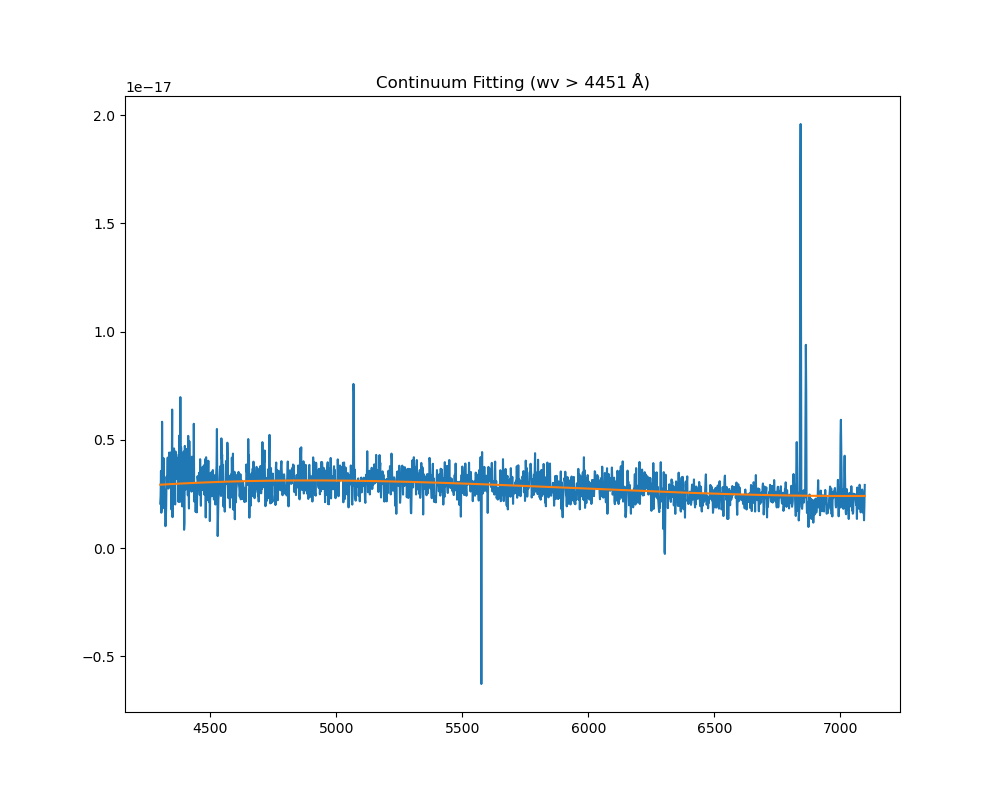

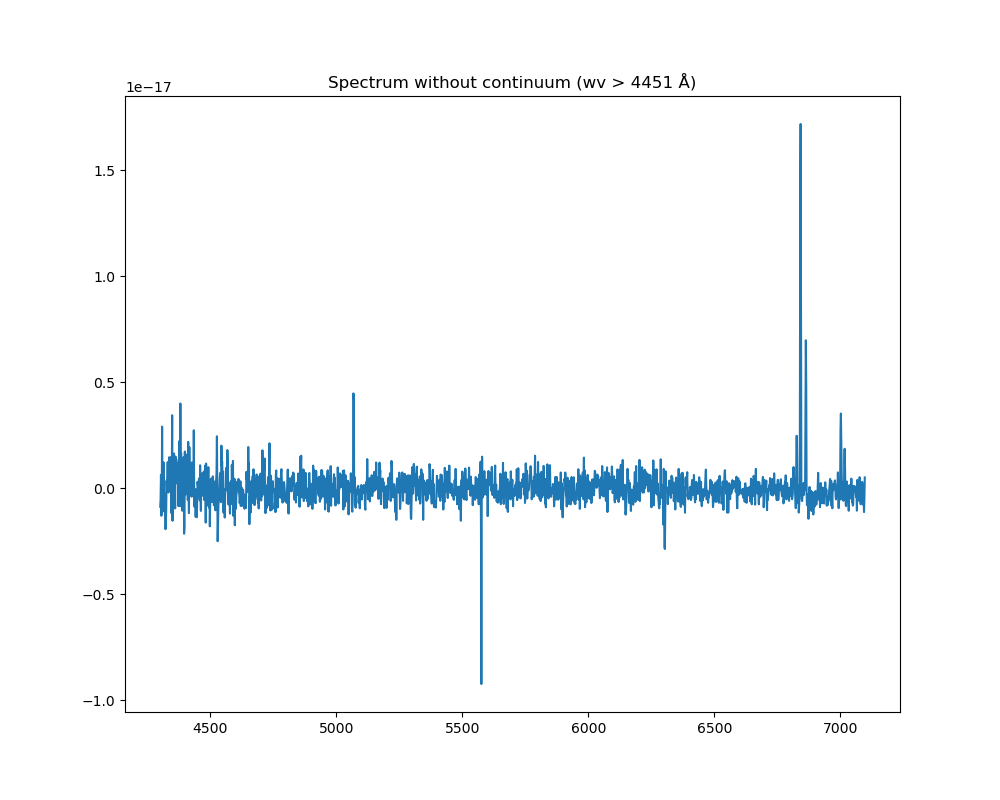

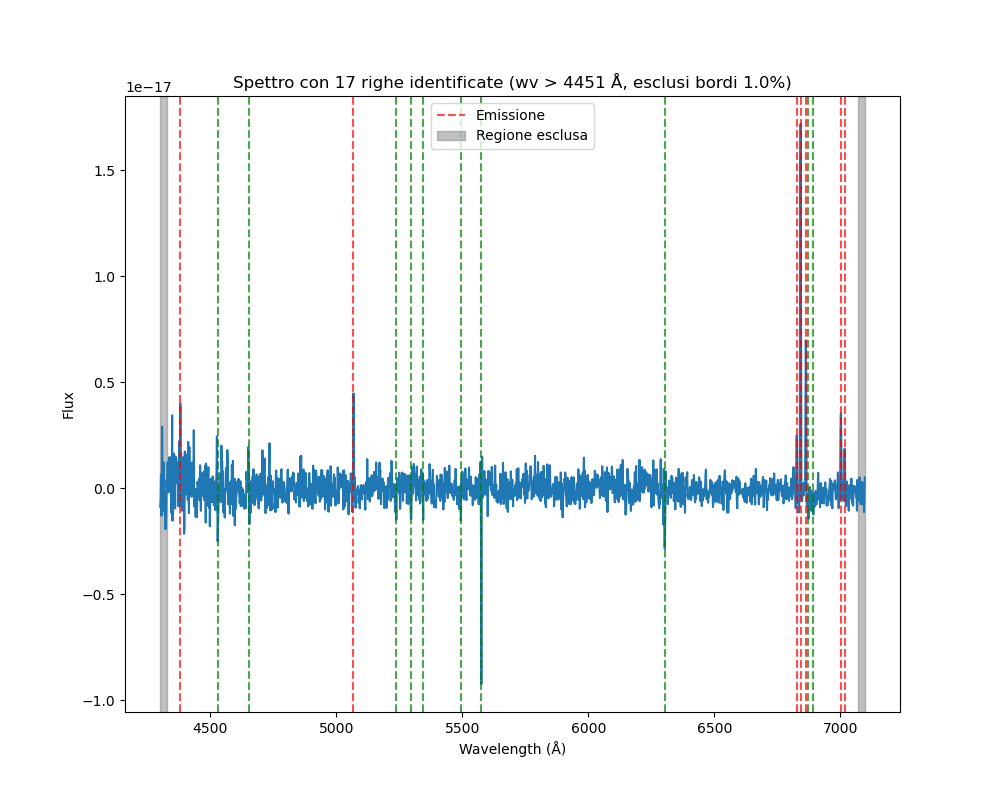

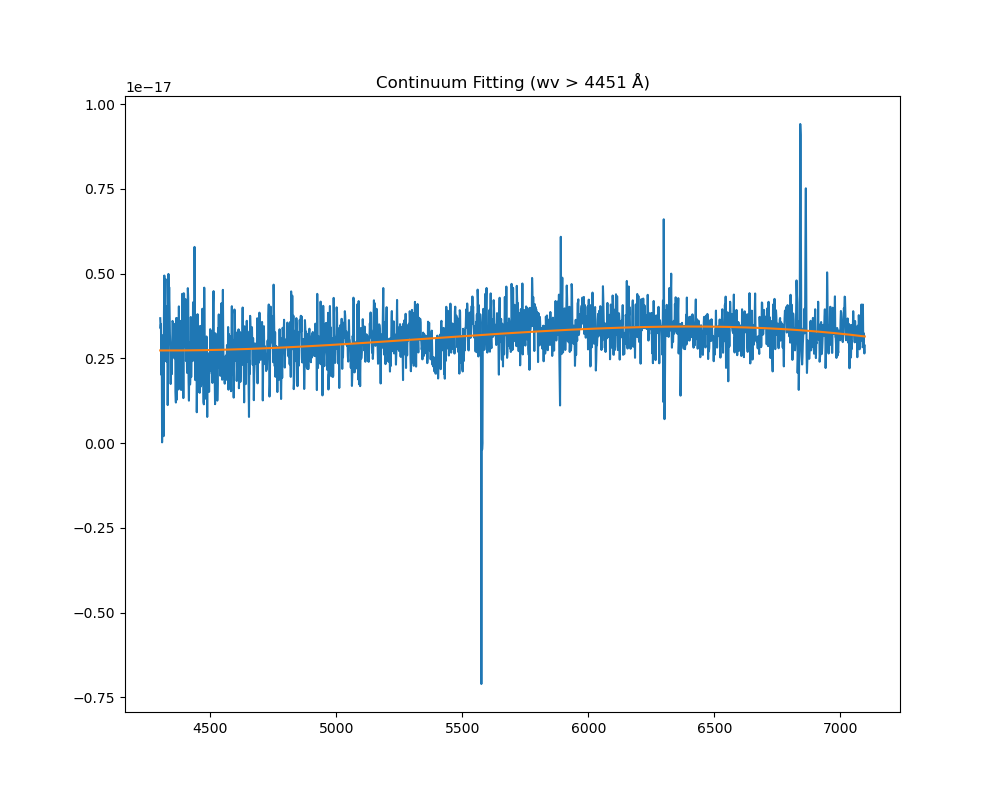

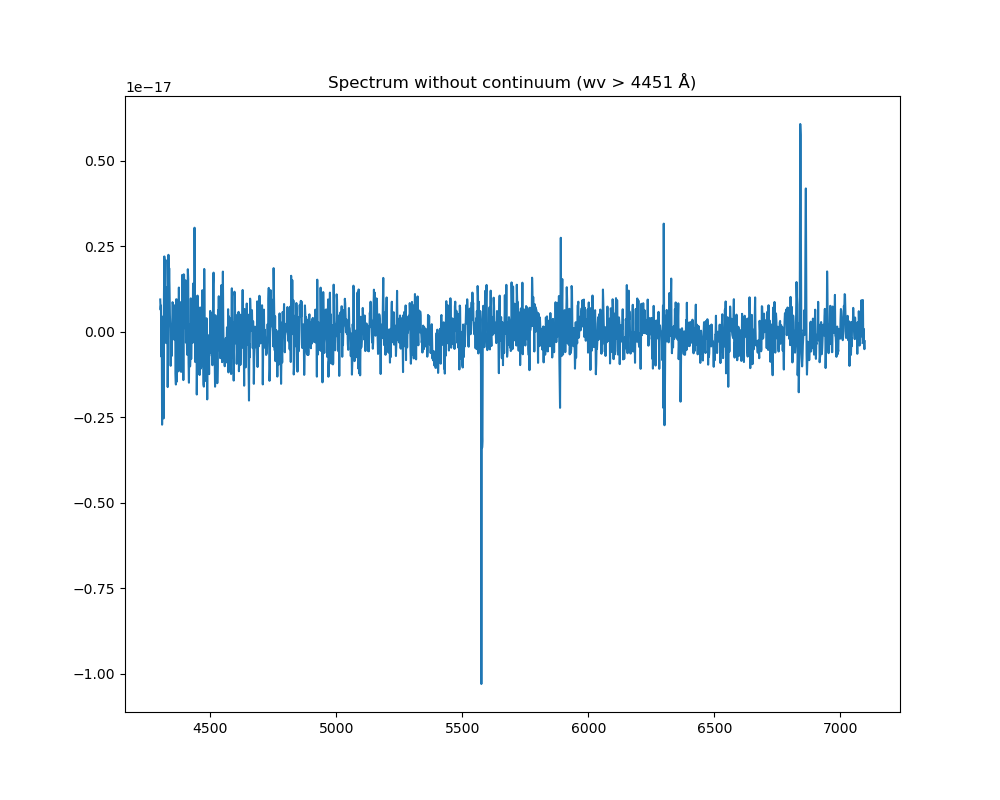

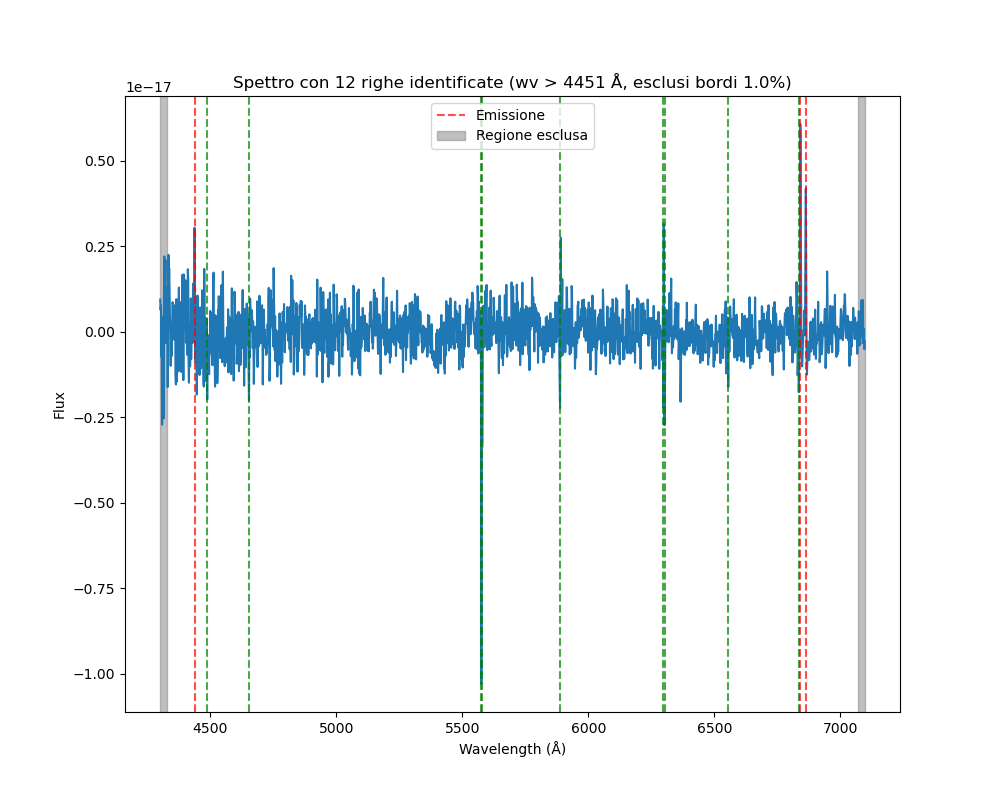

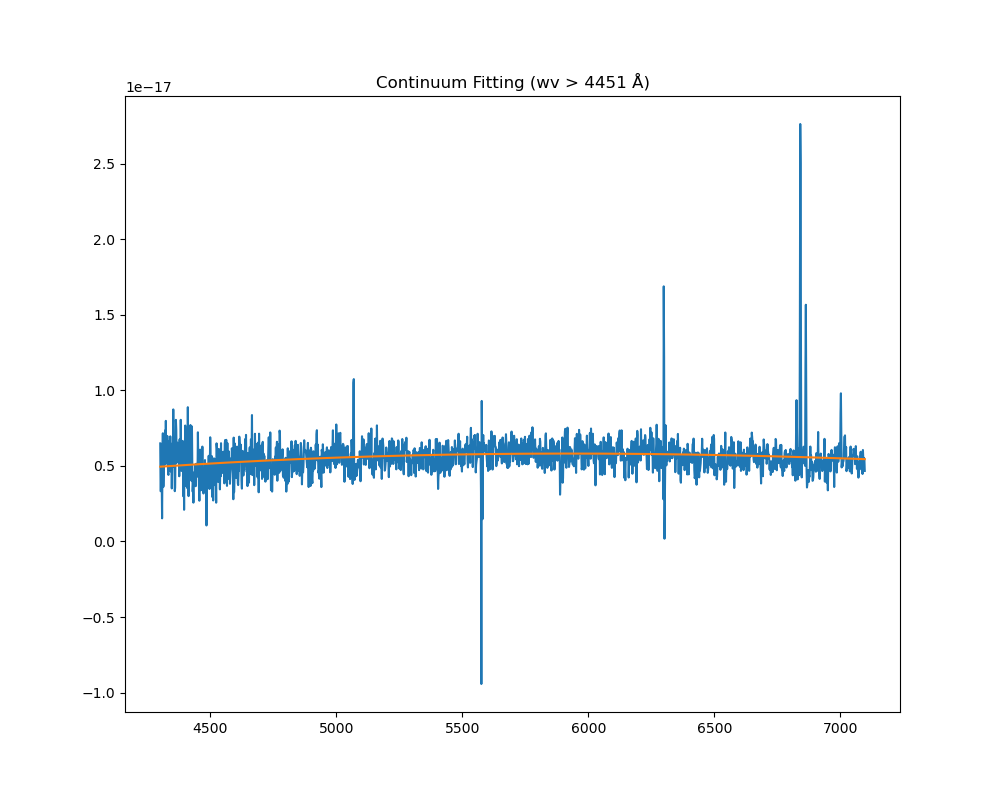

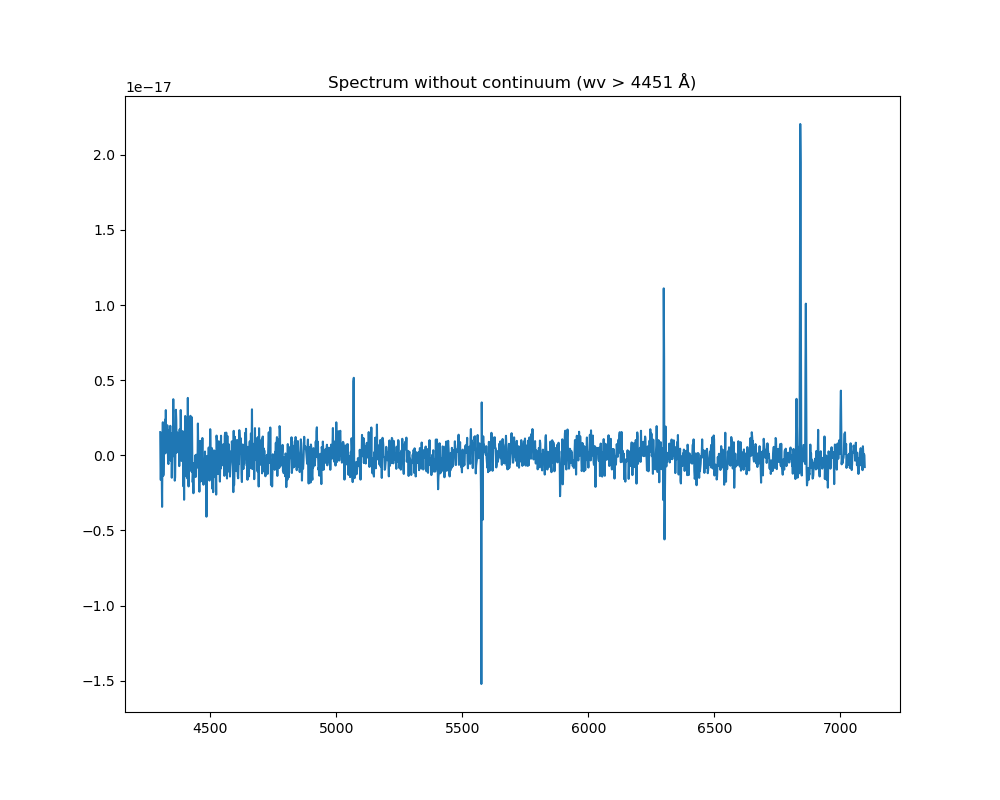

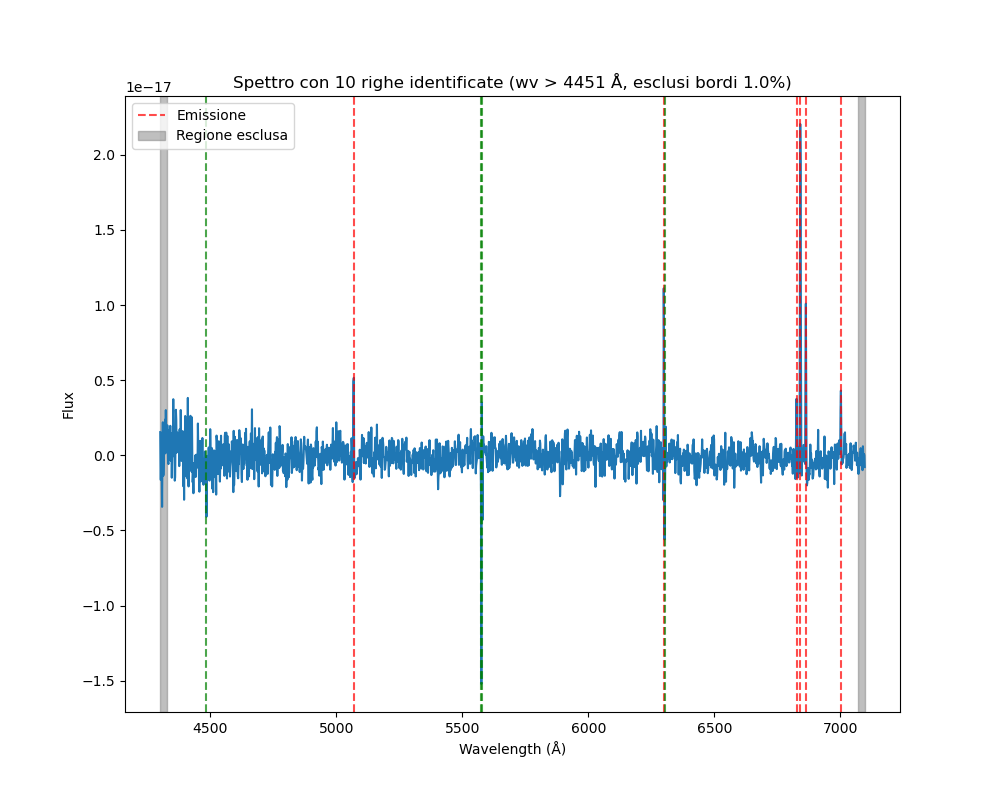

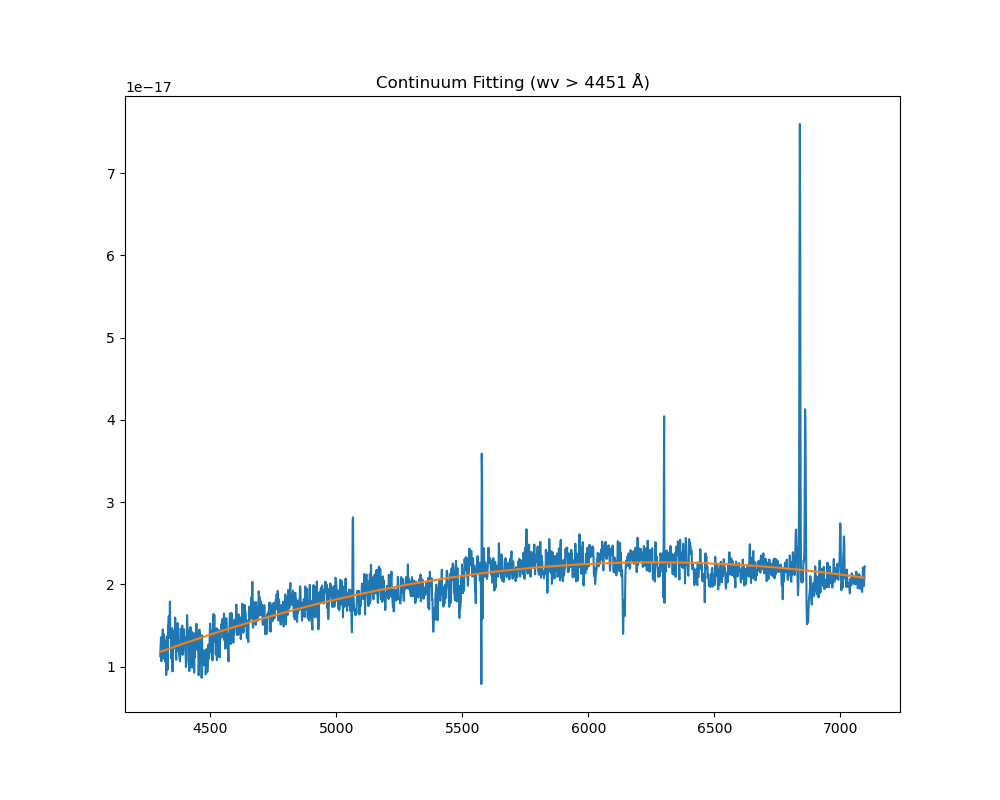

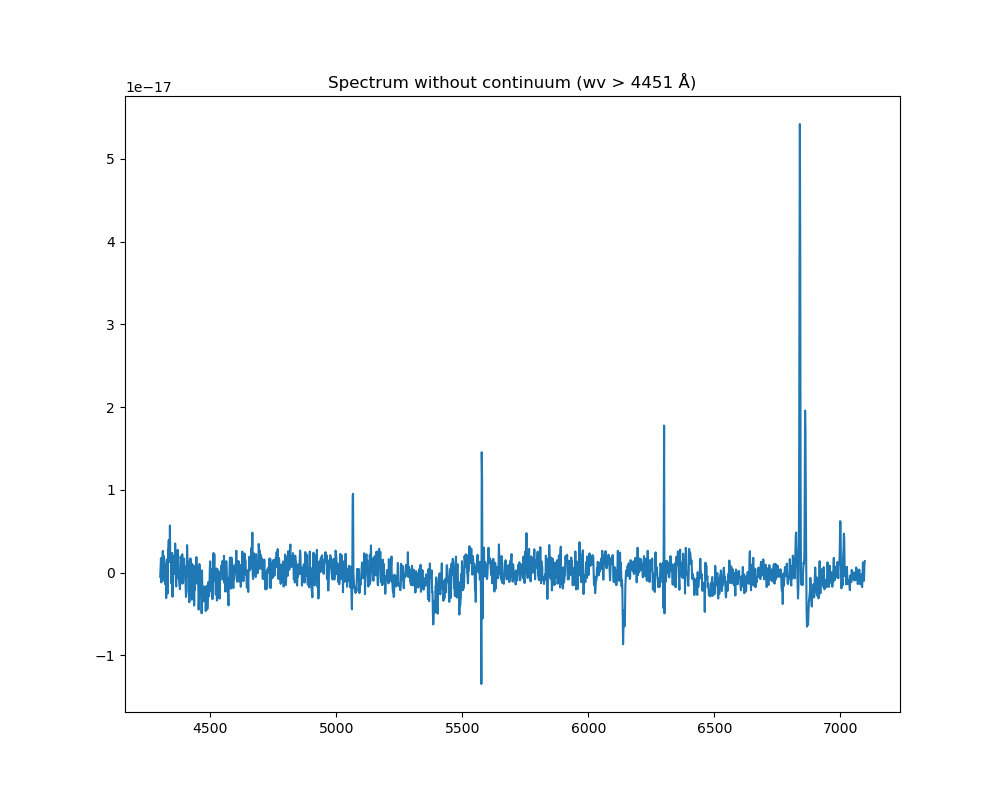

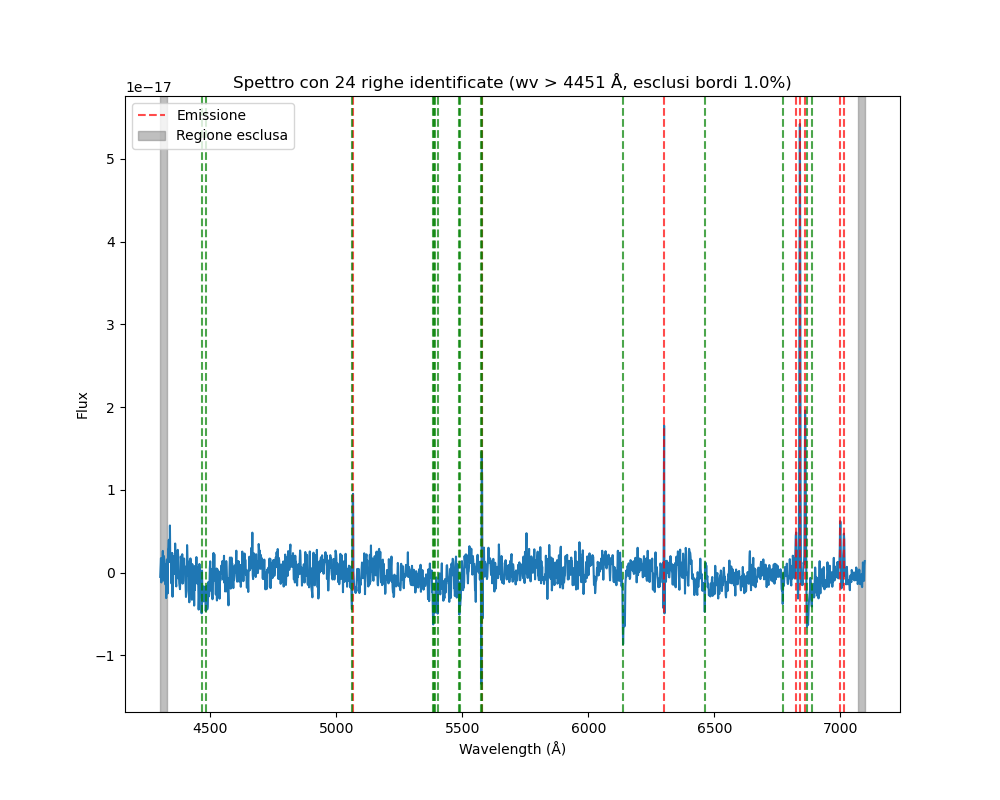

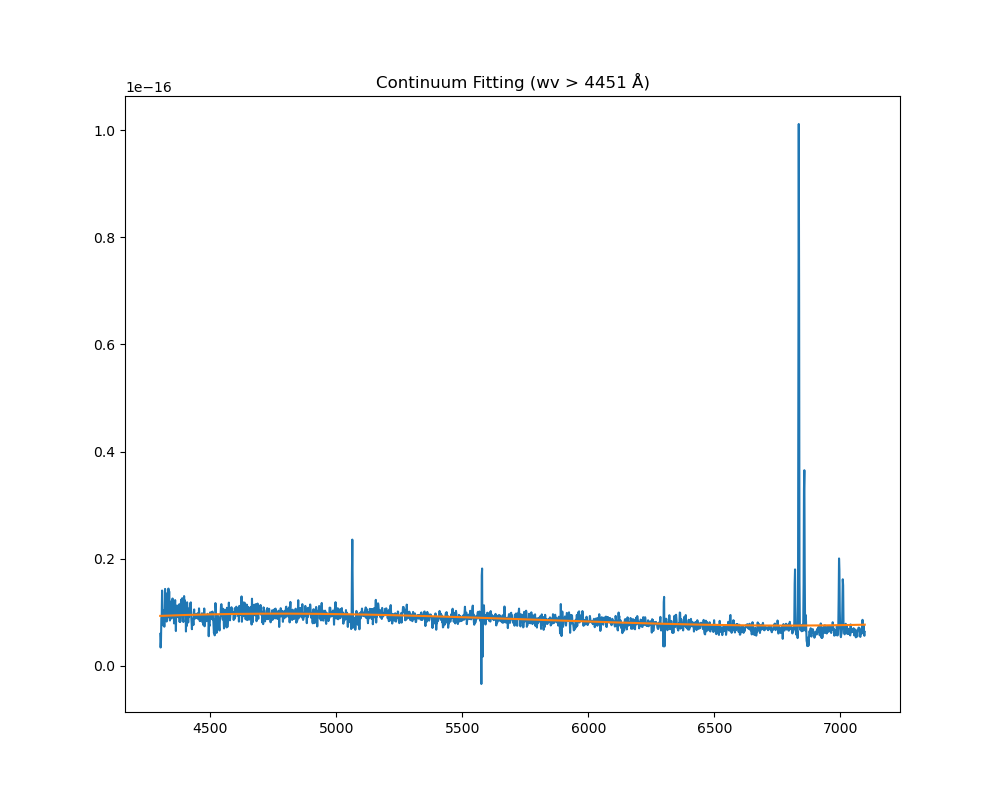

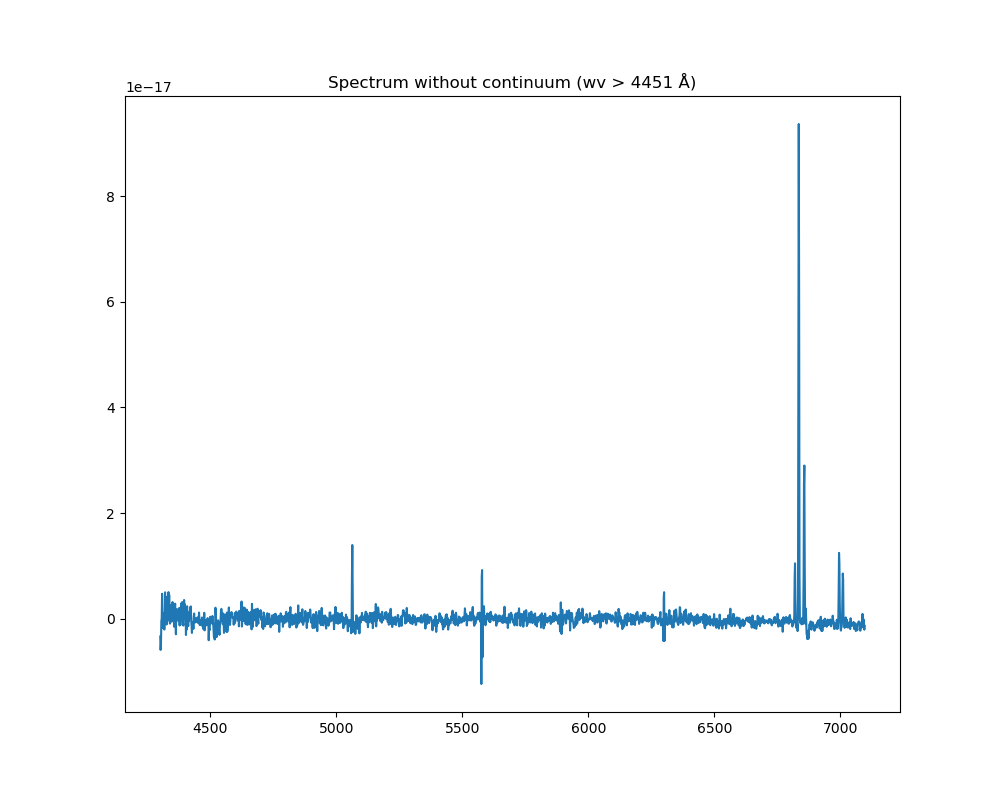

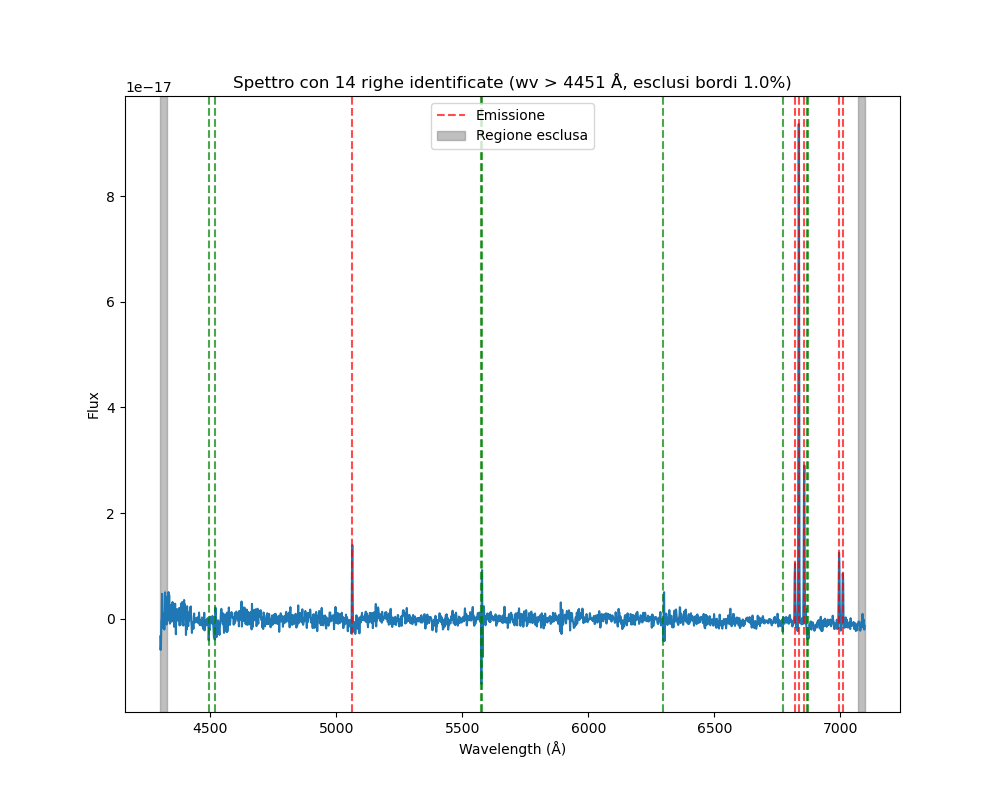

In [14]:
all_lines = []
noise_factor = [3, 3, 4, 4, 4]

# Filtra per lunghezze d'ondaù > 4451 Å
wv_mask = wv > 0
wv_filtered = wv[wv_mask]

# Definisci la percentuale di spettro da escludere ai bordi (es. 5% per lato)
edge_fraction = 0.01
n_points = len(wv_filtered)
start_idx = int(n_points * edge_fraction)
end_idx = int(n_points * (1 - edge_fraction))

# Crea gli array ritagliati per la regione centrale (già filtrata per wv > 4451)
wv_central = wv_filtered[start_idx:end_idx]

for i in range(len(peaks)):
    # Applica il filtro anche agli spettri
    spectra_filtered = spectra_1[i][wv_mask]
    spectra_err_filtered = spectra_err_1[i][wv_mask]
    
    # Usa lo spettro filtrato per il fitting del continuum
    spectrum = Spectrum(
        spectral_axis=wv_filtered * u.Angstrom,
        flux = spectra_filtered * 1e-16 *u.erg / (u.cm**2 * u.s * u.Angstrom),  
        uncertainty = StdDevUncertainty(spectra_err_filtered * 1e-16 *u.erg / (u.cm**2 * u.s * u.Angstrom))
    )
    
    g1_fit = fit_generic_continuum(spectrum, fitter=LinearLSQFitter())
    y_continuum_fitted = g1_fit(wv_filtered * u.Angstrom)
    
    f, ax = plt.subplots(figsize = (10,8))
    ax.plot(wv_filtered * u.Angstrom, spectra_filtered * 1e-16*u.erg / (u.cm**2 * u.s * u.Angstrom))
    ax.plot(wv_filtered * u.Angstrom, y_continuum_fitted)
    ax.set_title("Continuum Fitting (wv > 4451 Å)")
    
    flux_continuum_subtracted = spectrum.flux - y_continuum_fitted
    f2, ax2 = plt.subplots(figsize = (10,8))
    ax2.plot(wv_filtered * u.Angstrom, flux_continuum_subtracted)
    ax2.set_title("Spectrum without continuum (wv > 4451 Å)")
    
    # Crea lo spettro solo per la regione centrale (senza bordi, già filtrata per wv > 4451)
    spectrum_no_continuum_central = Spectrum(
        spectral_axis=wv_central * u.Angstrom,
        flux=flux_continuum_subtracted[start_idx:end_idx],
        uncertainty=StdDevUncertainty(spectra_err_filtered[start_idx:end_idx] * 1e-16 * u.erg / (u.cm**2 * u.s * u.Angstrom))
    )
    
    # Trova le righe solo nella regione centrale
    lines = find_lines_threshold(spectrum_no_continuum_central, noise_factor = noise_factor[i])
    print(f"Numero di righe trovate (regione centrale, wv > 4451 Å): {len(lines)}")
    print(lines)
    
    f3, ax3 = plt.subplots(figsize=(10,8))
    ax3.plot(wv_filtered, flux_continuum_subtracted.value)
    
    if len(lines) < 50:  # Solo se non sono troppe
        for line_pos in lines['line_center']:
            # Trova l'indice corrispondente nel flux per determinare il tipo di riga
            # Trova l'indice più vicino alla posizione della riga nell'array wv_central
            line_idx = np.argmin(np.abs(wv_central - line_pos.value))
            # Ottieni l'indice corrispondente nel flux completo
            flux_idx = start_idx + line_idx
            
            # Determina se è emissione (positiva) o assorbimento (negativa)
            if flux_continuum_subtracted[flux_idx].value > 0:
                # Riga di emissione - colore rosso
                ax3.axvline(x=line_pos.value, color='red', alpha=0.7, linestyle='--', 
                           label='Emissione' if line_pos == lines['line_center'][0] else "")
            else:
                # Riga di assorbimento - colore verde
                ax3.axvline(x=line_pos.value, color='green', alpha=0.7, linestyle='--',
                           label='Assorbimento' if line_pos == lines['line_center'][0] else "")
    
    # Aggiungi linee verticali per indicare i bordi esclusi
    ax3.axvspan(wv_filtered[0], wv_filtered[start_idx], alpha=0.5, color='gray', zorder=1, label='Regione esclusa')
    ax3.axvspan(wv_filtered[end_idx-1], wv_filtered[-1], alpha=0.5, color='gray', zorder=1)
    ax3.legend()
    
    ax3.set_title(f"Spettro con {len(lines)} righe identificate (wv > 4451 Å, esclusi bordi {edge_fraction*100:.1f}%)")
    ax3.set_xlabel('Wavelength (Å)')
    ax3.set_ylabel('Flux')
    all_lines.append(lines)

In [15]:
#reference wv in air
l_Hgam = 4340.5
l_HA = 6562.8
l_HB = 4861.3
l_NII_1 = 6548.1
l_NII_2 = 6583.4
l_SII_1 = 6717.0
l_SII_2 = 6731.3
l_OIII_1 = 4958.9
l_OIII_2 = 5006.8
l_He_1 = 5875.6

lines_1 = [l_HB, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_2 = [l_NII_1, l_HA, l_NII_2]
lines_3 = [l_HB, l_NII_1, l_HA, l_NII_2, l_SII_1]
lines_4 = [l_HB, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_5 = [l_HB, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_spectrum_1 = [5067.379999999774, 6827.099999999255,  6841.89999999925, 6862.619999999244, 7001.739999999203, 7016.539999999199]
lines_spectrum_2 = [6825.7, 6840.419999999251, 6862.619999999244]
lines_spectrum_3 = [5068.859999999773, 6825.619999999255, 6840.419999999251, 6862.619999999244, 7001.739999999203]
lines_spectrum_4 = [5065.899999999774, 6824.139999999255, 6838.939999999251, 6859.659999999245, 6998.779999999204, 7013.5799999992]
lines_spectrum_5 = [5062.939999999775, 6819.699999999257, 6834.499999999252, 6856.699999999246, 6994.339999999205, 7009.139999999201]

def redshift(lines, lines_spectrum):
    z = np.zeros(len(lines))
    for i in range(len(lines)):
        z[i] = lines_spectrum[i].value / lines[i] - 1
    z_mean = np.mean(z)
    z_std = np.std(z)
    return z_mean, z_std
    
def redshift_hand(lines, lines_spectrum):
    z = np.zeros(len(lines))
    for i in range(len(lines)):
        z[i] = lines_spectrum[i]/ lines[i] - 1
    z_mean = np.mean(z)
    z_std = np.std(z)
    return z_mean, z_std
    
z_1_mean, z_1_std = redshift_hand(lines_1, lines_spectrum_1)    
z_2_mean, z_2_std = redshift_hand(lines_2, lines_spectrum_2)    
z_3_mean, z_3_std = redshift_hand(lines_3, lines_spectrum_3)    
z_4_mean, z_4_std = redshift_hand(lines_4, lines_spectrum_4)
z_5_mean, z_5_std = redshift_hand(lines_5, lines_spectrum_5) 

z = [z_1_mean, z_2_mean, z_3_mean, z_4_mean, z_5_mean]
z_err = [z_1_std, z_2_std, z_3_std, z_4_std, z_5_std]

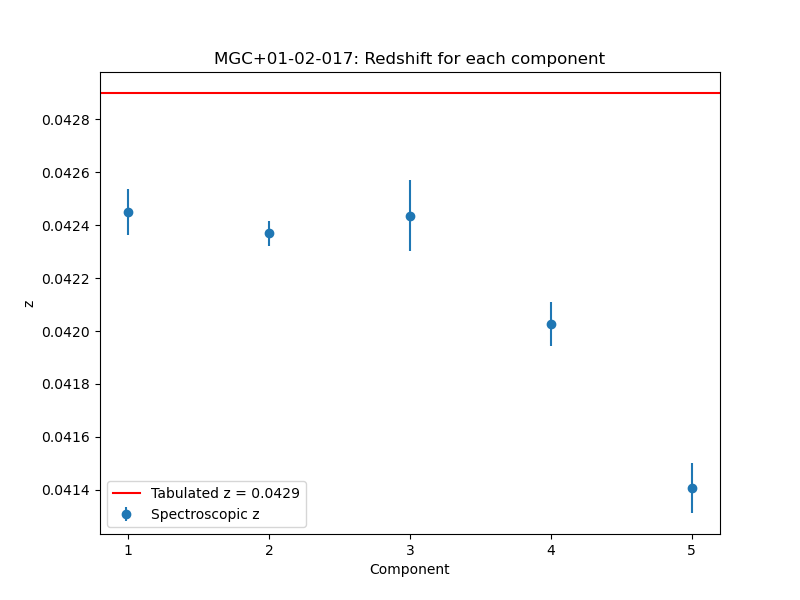

In [16]:
plt.figure(figsize=(8, 6))
comp = [1, 2, 3, 4, 5]
plt.errorbar(comp, z, z_err, ls='none', marker = 'o', label = 'Spectroscopic z')
plt.xlabel('Component')
plt.ylabel('z')
plt.xticks(comp)
plt.axhline(0.0429, color = 'red', label = 'Tabulated z = 0.0429')
plt.title('MGC+01-02-017: Redshift for each component')
plt.legend()
plt.savefig('Redshift_MGC+01-02-017', bbox_inches='tight')

red_table = np.column_stack((z, z_err))
np.savetxt('redshift.txt', red_table, header='redshift redshift_error', fmt='%.5f',delimiter='\t')

## S/N emission lines 

In [17]:
def SNR_line(wv, wv_line, spectra, peaks): 
    Signal = []
    Noise = []
    SNR = []
    for i in range(len(peaks)):
        left_region = (wv > wv_line[i]-15)*(wv < wv_line[i]-5) 
        right_region = (wv > wv_line[i]+5)*(wv < wv_line[i]+15) 
        clean_mask = left_region | right_region

        mask = (wv > wv_line[i]-4)*(wv < wv_line[i]+4)
        wv_bin = np.array(np.where(mask == True))
        flux = spectra[i, mask] - np.mean(spectra[i, clean_mask])
        signal = (np.trapz(flux, wv[mask]))
        noise = np.std(spectra[i, clean_mask] - np.mean(spectra[i, clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
        SNR.append(signal/noise)
        Signal.append(signal)
        Noise.append(noise)
   # print(SNR)
   # print(Signal)
   # print(Noise)
    return SNR, Signal, Noise
    
def SNR_OIII_line(wv, OIII_1, OIII_2, wv_line, spectra, peaks):
    Signal = []
    Noise = []
    SNR = []
    for i in range(len(peaks)):
        left_region = (wv > OIII_1[i]-15)*(wv < OIII_1[i]-5) 
        right_region = (wv > OIII_2[i]+5)*(wv < OIII_2[i]+15) 
        clean_mask = left_region | right_region

        mask = (wv > wv_line[i]-4)*(wv < wv_line[i]+4)
        wv_bin = np.array(np.where(mask == True))
        flux = spectra[i, mask] - np.mean(spectra[i, clean_mask])
        signal = (np.trapz(flux, wv[mask]))
        noise = np.std(spectra[i, clean_mask] - np.mean(spectra[i, clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
        SNR.append(signal/noise)
        Signal.append(signal)
        Noise.append(noise)
    return SNR, Signal, Noise 
    
def SNR_SII_line(wv, SII_1, SII_2, wv_line, spectra, peaks):
    Signal = []
    Noise = []
    SNR = []
    for i in range(len(peaks)):
        left_region = (wv > SII_1[i]-15)*(wv < SII_1[i]-5) 
        right_region = (wv > SII_2[i]+5)*(wv < SII_2[i]+15) 
        clean_mask = left_region | right_region

        mask = (wv > wv_line[i]-4)*(wv < wv_line[i]+4)
        wv_bin = np.array(np.where(mask == True))
        flux = spectra[i, mask] - np.mean(spectra[i, clean_mask])
        signal = (np.trapz(flux, wv[mask]))
        noise = np.std(spectra[i, clean_mask] - np.mean(spectra[i, clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
        SNR.append(signal/noise)
        Signal.append(signal)
        Noise.append(noise)
    return SNR, Signal, Noise 

def SNR_HA_NII(wv, NII_1, NII_2, wv_line, spectra, peaks):
    Signal = []
    Noise = []
    SNR = []
    for i in range(len(peaks)):
        left_region = (wv > NII_1[i]-15)*(wv < NII_1[i]-5) 
        right_region = (wv > NII_2[i]+5)*(wv < NII_2[i]+15) 
        clean_mask = left_region | right_region

        mask = (wv > wv_line[i]-4)*(wv < wv_line[i]+4)
        wv_bin = np.array(np.where(mask == True))
        flux = spectra[i, mask] - np.mean(spectra[i, clean_mask])
        signal = (np.trapz(flux, wv[mask]))
        noise = np.std(spectra[i, clean_mask] - np.mean(spectra[i, clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
        SNR.append(signal/noise)
        Signal.append(signal)
        Noise.append(noise)
    return SNR, Signal, Noise  

In [18]:
l_Hgam = []
l_HA = []
l_HB = []
l_NII_1 = []
l_NII_2 = []
l_SII_1 = []
l_SII_2 = []
l_OIII_1 = []
l_OIII_2 = []
l_He_1 = []
l_HeII = []
l_OI = []
for i in range(len(spectra_1)):
    l_Hgam.append(4340.5*(1+z[i]))
    l_HA.append(6562.8*(1+z[i]))
    l_HB.append(4861.3*(1+z[i]))
    l_NII_1.append(6548.1*(1+z[i]))
    l_NII_2.append(6583.4*(1+z[i]))
    l_SII_1.append(6717.0*(1+z[i]))
    l_SII_2.append(6731.3*(1+z[i]))
    l_OIII_1.append(4958.9*(1+z[i]))
    l_OIII_2.append(5006.8*(1+z[i]))
    l_He_1.append(5875.6*(1+z[i]))
    l_HeII.append(4685.7*(1+z[i]))
    l_OI.append(6300.3*(1+z[i]))

In [19]:
def save_snr_HB(wv, l_HB, spectra_list, peaks, output_dirs, file_prefixes):
    """
    Generalizza l'analisi SNR per multiple spectra
    
    Parameters:
    - wv: wavelength array
    - l_HB: line parameter
    - spectra_list: lista degli spettri da analizzare
    - peaks: peaks parameter
    - output_dirs: lista delle directory di output
    - file_prefixes: lista dei prefissi per i nomi dei file
    """
    
    
    for i, (spectra, output_dir, file_prefix) in enumerate(zip(spectra_list, output_dirs, file_prefixes)):
        # Calcola SNR per lo spettro corrente
        SNR, signal, noise = SNR_line(wv, l_HB, spectra, peaks)
        
        # Crea il DataFrame
        df = pd.DataFrame({
        'SNR': SNR,
        'Signal': signal,
        'Noise': noise }, index=[f'Component_{i}' for i in range(1, len(peaks)+ 1)])
        
        # Salva il file CSV
        df_path = os.path.join(output_dir, f'{file_prefix}.csv')
        df.to_csv(df_path, float_format='%.3f')
        print(f'{file_prefix}.csv', df)

def save_snr_OIII(wv, OIII_1, OIII_2, wv_line, spectra_list, peaks, output_dirs, file_prefixes):
    
    for i, (spectra, output_dir, file_prefix) in enumerate(zip(spectra_list, output_dirs, file_prefixes)):
        # Calcola SNR per lo spettro corrente
        SNR, signal, noise = SNR_OIII_line(wv, OIII_1, OIII_2, wv_line, spectra, peaks)
        
        # Crea il DataFrame
        df = pd.DataFrame({
        'SNR': SNR,
        'Signal': signal,
        'Noise': noise }, index=[f'Component_{i}' for i in range(1, len(peaks)+ 1)])
        
        # Salva il file CSV
        df_path = os.path.join(output_dir, f'{file_prefix}.csv')
        df.to_csv(df_path, float_format='%.3f')
        print(f'{file_prefix}.csv', df)
        
def save_snr_SII(wv, SII_1, SII_2, wv_line, spectra_list, peaks, output_dirs, file_prefixes):
    
    for i, (spectra, output_dir, file_prefix) in enumerate(zip(spectra_list, output_dirs, file_prefixes)):
        # Calcola SNR per lo spettro corrente
        SNR, signal, noise = SNR_SII_line(wv, SII_1, SII_2, wv_line, spectra, peaks)
        
        # Crea il DataFrame
        df = pd.DataFrame({
        'SNR': SNR,
        'Signal': signal,
        'Noise': noise }, index=[f'Component_{i}' for i in range(1, len(peaks)+ 1)])
        
        # Salva il file CSV
        df_path = os.path.join(output_dir, f'{file_prefix}.csv')
        df.to_csv(df_path, float_format='%.3f')
        print(f'{file_prefix}.csv', df)


def save_snr_HA_NII(wv, NII_1, NII_2, wv_line, spectra_list, peaks, output_dirs, file_prefixes):
    
    for i, (spectra, output_dir, file_prefix) in enumerate(zip(spectra_list, output_dirs, file_prefixes)):
        # Calcola SNR per lo spettro corrente
        SNR, signal, noise = SNR_HA_NII(wv, NII_1, NII_2, wv_line, spectra, peaks)
        
        # Crea il DataFrame
        df = pd.DataFrame({
        'SNR': SNR,
        'Signal': signal,
        'Noise': noise }, index=[f'Component_{i}' for i in range(1, len(peaks)+ 1)])
        
        # Salva il file CSV
        df_path = os.path.join(output_dir, f'{file_prefix}.csv')
        df.to_csv(df_path, float_format='%.3f')
        print(f'{file_prefix}.csv', df)

def save_snr(wv, wv_line, spectra_list, peaks, output_dirs, file_prefixes):
    
    for i, (spectra, output_dir, file_prefix) in enumerate(zip(spectra_list, output_dirs, file_prefixes)):
        # Calcola SNR per lo spettro corrente
        SNR, signal, noise = SNR_line(wv, wv_line, spectra, peaks)
        
        # Crea il DataFrame
        df = pd.DataFrame({
        'SNR': SNR,
        'Signal': signal,
        'Noise': noise }, index=[f'Component_{i}' for i in range(1, len(peaks)+ 1)])
        
        # Salva il file CSV
        df_path = os.path.join(output_dir, f'{file_prefix}.csv')
        df.to_csv(df_path, float_format='%.3f')
        print(f'{file_prefix}.csv', df)

In [20]:
spectra_list = [spectra_1, spectra_2, spectra_3]
output_dirs = ['1Sigma', '2Sigma', '3Sigma']
file_prefixes = ['SNR_HB_1s', 'SNR_HB_2s', 'SNR_HB_3s']
save_snr_HB(wv, l_HB, spectra_list, peaks, output_dirs, file_prefixes)

file_prefixes = ['SNR_OIII_1_1s', 'SNR_OIII_1_2s', 'SNR_OIII_1_3s']
save_snr_OIII(wv, l_OIII_1, l_OIII_2, l_OIII_1, spectra_list, peaks, output_dirs, file_prefixes)

file_prefixes = ['SNR_OIII_2_1s', 'SNR_OIII_2_2s', 'SNR_OIII_2_3s']
save_snr_OIII(wv, l_OIII_1, l_OIII_2, l_OIII_2, spectra_list, peaks, output_dirs, file_prefixes)

file_prefixes = ['SNR_SII_1_1s', 'SNR_SII_1_2s', 'SNR_SII_1_3s']
save_snr_SII(wv, l_SII_1, l_SII_2, l_SII_1, spectra_list, peaks, output_dirs, file_prefixes)

file_prefixes = ['SNR_SII_2_1s', 'SNR_SII_2_2s', 'SNR_SII_2_3s']
save_snr_SII(wv, l_SII_1, l_SII_2, l_SII_2, spectra_list, peaks, output_dirs, file_prefixes)

file_prefixes = ['SNR_NII_1_1s', 'SNR_NII_1_2s', 'SNR_NII_1_3s']
save_snr_HA_NII(wv, l_NII_1, l_NII_2, l_NII_1, spectra_list, peaks, output_dirs, file_prefixes)

file_prefixes = ['SNR_NII_2_1s', 'SNR_NII_2_2s', 'SNR_NII_2_3s']
save_snr_HA_NII(wv, l_NII_1, l_NII_2, l_NII_2, spectra_list, peaks, output_dirs, file_prefixes)

file_prefixes = ['SNR_HA_1s', 'SNR_HA_2s', 'SNR_HA_3s']
save_snr_HA_NII(wv, l_NII_1, l_NII_2, l_HA, spectra_list, peaks, output_dirs, file_prefixes)

file_prefixes = ['SNR_HeII_1s', 'SNR_HeII_2s', 'SNR_HeII_3s']
save_snr(wv, l_HeII, spectra_list, peaks, output_dirs, file_prefixes)

file_prefixes = ['SNR_OI_1s', 'SNR_OI_2s', 'SNR_OI_3s']
save_snr(wv, l_OI, spectra_list, peaks, output_dirs, file_prefixes)

SNR_HB_1s.csv                    SNR    Signal     Noise
Component_1   7.972904  0.134769  0.016903
Component_2   4.707190  0.057013  0.012112
Component_3   7.306601  0.172642  0.023628
Component_4   9.136508  0.352128  0.038541
Component_5  23.101201  0.470998  0.020388
SNR_HB_2s.csv                    SNR    Signal     Noise
Component_1  11.585690  0.389444  0.033614
Component_2   5.223937  0.155948  0.029853
Component_3  11.645766  0.357065  0.030661
Component_4  11.435636  0.536676  0.046930
Component_5  20.468295  0.806668  0.039411
SNR_HB_3s.csv                    SNR    Signal     Noise
Component_1  13.845594  0.486496  0.035137
Component_2   7.003156  0.178322  0.025463
Component_3  10.425263  0.434517  0.041679
Component_4  13.599170  0.767349  0.056426
Component_5  20.940192  1.194769  0.057056
SNR_OIII_1_1s.csv                   SNR    Signal     Noise
Component_1  1.481938  0.025851  0.017444
Component_2 -0.803842 -0.013382  0.016648
Component_3 -1.139020 -0.028121  0.02468